In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
import cv2
from sklearn.model_selection import train_test_split

In [3]:
dir = 'American_Sign_Language_Letters_Multiclass/'

In [4]:
def load_df(dir_path):
    df = {
        'filename': [],
        'label': []
    }
    classes = os.listdir(dir_path)
    for c in classes:
        path = dir_path + '/' + c

        img_paths = os.listdir(path)

        for img_path in img_paths:
            df['filename'].append(c + '/' + img_path)
            df['label'].append(c)
        
    df = pd.DataFrame(df)
    return df

train_df = load_df(dir)

In [5]:
train_df

,filename,label
0,A/A0001_test.jpg,A
1,A/A0002_test.jpg,A
2,A/A0003_test.jpg,A
3,A/A0004_test.jpg,A
4,A/A0005_test.jpg,A
...,...,...
3403,Z/Z8_jpg.rf.2568ebce12fca75ea01fdba52145402f.jpg,Z
3404,Z/Z8_jpg.rf.2d9d5a30a4d9248bc91940c7c0fca4ef.jpg,Z
3405,Z/Z8_jpg.rf.81357aeb1a89b914fc16d5a0418db9ff.jpg,Z
3406,Z/Z900.jpg,Z


In [ ]:
def show_img(path, row):
    filename = list(row['filename'])[0]
    label = list(row['label'])[0]
    image = cv2.imread(path + '/' + filename) #read the data
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGBA) #convert it to a color channel
    plt.imshow(image)
    plt.title(label)
    plt.axis('off')
    plt.show()

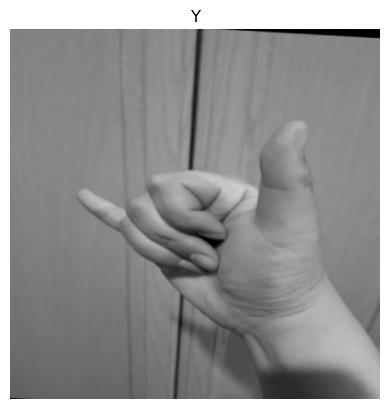

In [66]:
show_img(dir, train_df.sample(1))

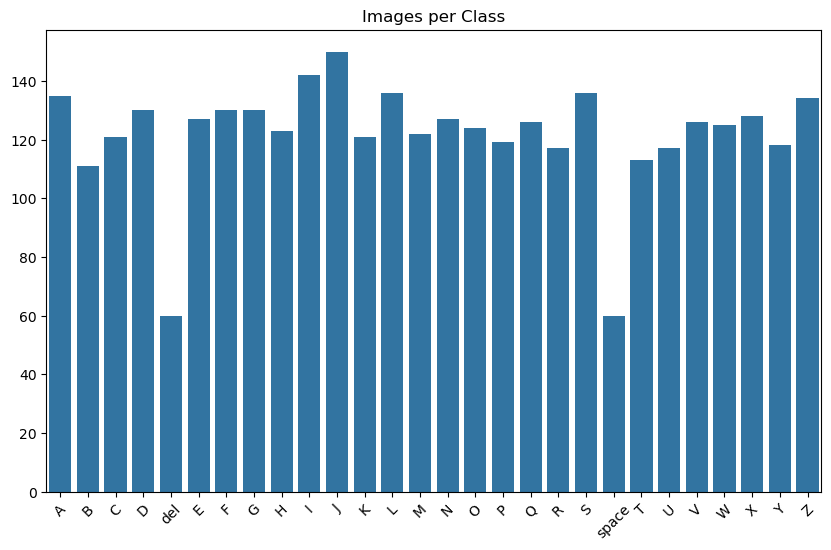

In [ ]:
def check_class_distribution(dataset_path):
    counts = {}
    for folder in os.listdir(dataset_path):
        counts[folder] = len(os.listdir(os.path.join(dataset_path, folder)))
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts.keys()), y=list(counts.values()))
    plt.xticks(rotation=45)
    plt.title("Images per Class")
    plt.show()

check_class_distribution(dir)

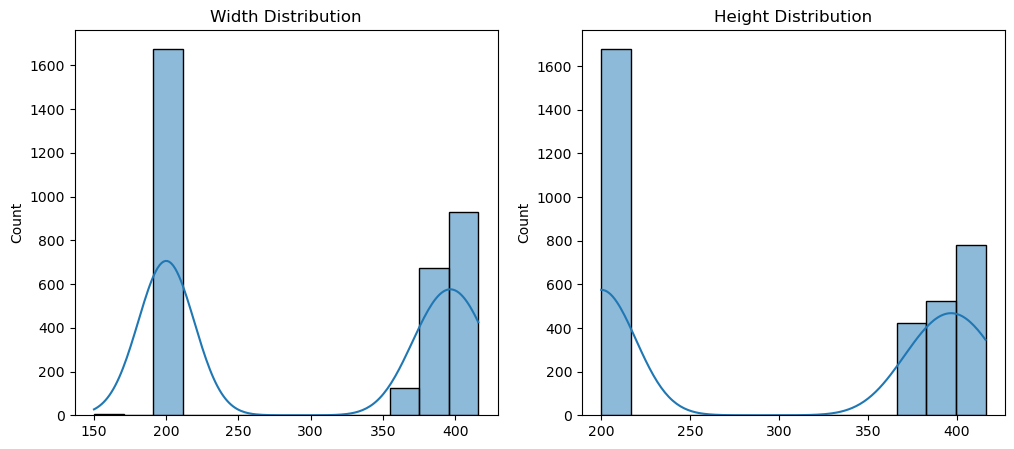

In [68]:
from PIL import Image

def analyze_dimensions(dataset_path):
    widths, heights = [], []
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.endswith(('jpg', 'png', 'jpeg')):
                img = Image.open(os.path.join(root, file))
                w, h = img.size
                widths.append(w)
                heights.append(h)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(widths, kde=True).set_title("Width Distribution")
    plt.subplot(1, 2, 2)
    sns.histplot(heights, kde=True).set_title("Height Distribution")
    plt.show()

analyze_dimensions(dir)

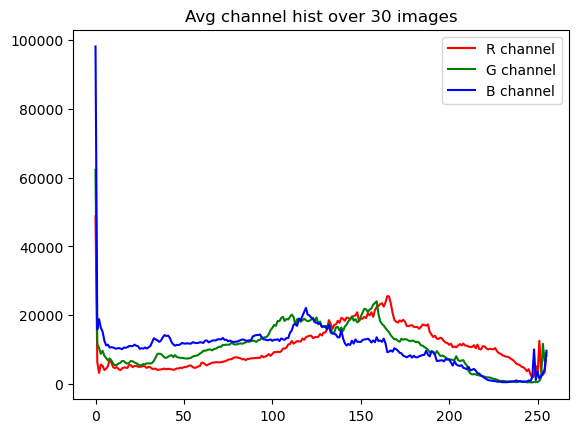

In [73]:
import os, random 
def plot_color_distribution_dir(dir_path, sample_n=20):
    imgs = []
    for root, _, files in os.walk(dir_path):
        for f in files:
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                imgs.append(os.path.join(root, f))
    imgs = random.sample(imgs, min(sample_n, len(imgs)))
    acc = np.zeros((3,256), dtype=np.float64)
    for p in imgs:
        arr = np.array(Image.open(p).convert('RGB'))
        for i in range(3):
            acc[i] += np.histogram(arr[:,:,i], bins=256, range=(0,256))[0]
    for i, col in enumerate(('r','g','b')):
        plt.plot(acc[i], color=col, label=f'{col.upper()} channel')
    plt.legend(); plt.title(f'Avg channel hist over {len(imgs)} images'); plt.show()

plot_color_distribution_dir('American_Sign_Language_Letters_Multiclass', sample_n=30)